In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [28]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ["MPLCONFIGDIR"] = f"/tmp/{os.environ['USER']}_matplotlib_cache"
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from cogwheel import gw_plotting, plotting, utils
from cogwheel.likelihood.marginalization.coherent_score_lensing import bootstrap_bayes_factors
sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from generate_injection_params import generate_injection_parameters
from helpers import load_event_data_and_posterior_samples, plot_posterior_samples, get_pII_median_span, expected_lnB

### get injection parameters

In [3]:
approximant = 'IMRPhenomXPHM'
save_fn = f'/home/abbye.williams/GWPE/data/injections/{approximant}/injection_params_{approximant}.pkl'

# I used the following code to generate the injection parameters:
# injection_params = generate_injection_parameters(100, approximant)
# save_fn = f'/home/abbye.williams/GWPE/data/injections/injection_params_{approximant}.pkl'
# injection_params.to_pickle(save_fn)

# load the injection parameters:
injection_params = pd.read_pickle(save_fn)

/home/abbye.williams/cogwheel/cogwheel/plotting.py:517: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.imshow(pdf, origin='lower', aspect='auto', extent=extent,
/home/abbye.williams/cogwheel/cogwheel/plotting.py:517: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(pdf, origin='lower', aspect='auto', extent=extent,


Text(0.5, 0.97, 'Injection parameters (Halton)')

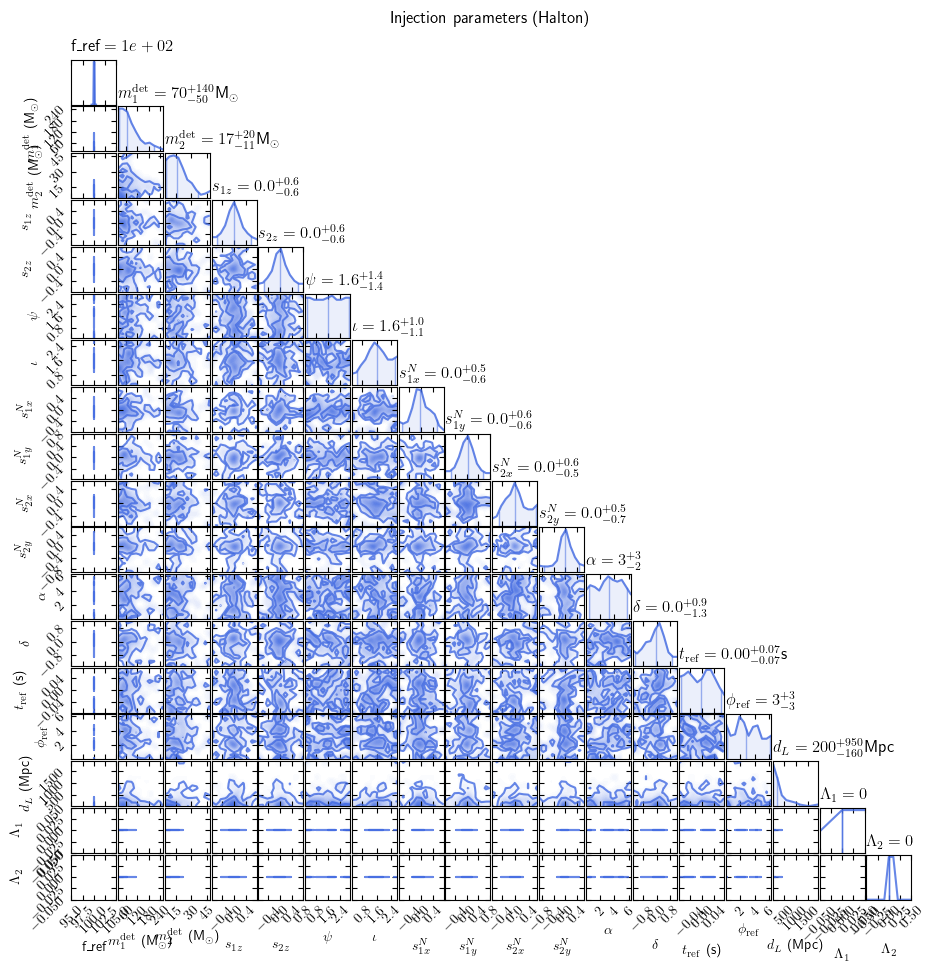

In [4]:
# do these look reasonable?
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))
cp = gw_plotting.CornerPlot(injection_params, injection_params.columns.to_list(), **corner_plot_kwargs)
cp.plot()
cp.fig.suptitle('Injection parameters (Halton)', y=0.97)


### PE results & mismatch

In [5]:
# for which events do we actually have posterior samples?
resdir = f'/home/abbye.williams/GWPE/data/injections/{approximant}/IntrinsicLVCPrior'
seed = 12
nevents = 60
idx_existing = []
for idx in range(nevents):
    # load this sample
    eventname = f'GW{seed}_{idx}'
    eventdir = os.path.join(resdir, eventname)
    try:
        event_data, samples = load_event_data_and_posterior_samples(eventdir, eventname)
        idx_existing.append(idx)
    except FileNotFoundError:
        print(f"no samples for idx {idx}. continuing")
        continue

no samples for idx 0. continuing
no samples for idx 1. continuing
no samples for idx 2. continuing
loaded posterior samples for GW12_3 run 0
loaded posterior samples for GW12_4 run 0
no samples for idx 5. continuing
loaded posterior samples for GW12_6 run 0
loaded posterior samples for GW12_7 run 0
loaded posterior samples for GW12_8 run 0
loaded posterior samples for GW12_9 run 0
loaded posterior samples for GW12_10 run 0
no samples for idx 11. continuing
loaded posterior samples for GW12_12 run 0
no samples for idx 13. continuing
no samples for idx 14. continuing
loaded posterior samples for GW12_15 run 0
loaded posterior samples for GW12_16 run 0
no samples for idx 17. continuing
loaded posterior samples for GW12_18 run 0
no samples for idx 19. continuing
no samples for idx 20. continuing
no samples for idx 21. continuing
no samples for idx 22. continuing
no samples for idx 23. continuing
no samples for idx 24. continuing
loaded posterior samples for GW12_25 run 0
no samples for idx

loaded posterior samples for GW12_29 run 0
loaded posterior samples for GW12_30 run 0
loaded posterior samples for GW12_31 run 0
no samples for idx 32. continuing
loaded posterior samples for GW12_33 run 0
no samples for idx 34. continuing
loaded posterior samples for GW12_35 run 0
no samples for idx 36. continuing
loaded posterior samples for GW12_37 run 0
loaded posterior samples for GW12_38 run 0
loaded posterior samples for GW12_39 run 0
no samples for idx 40. continuing
no samples for idx 41. continuing
loaded posterior samples for GW12_42 run 0
loaded posterior samples for GW12_43 run 0
no samples for idx 44. continuing
no samples for idx 45. continuing
no samples for idx 46. continuing
no samples for idx 47. continuing
no samples for idx 48. continuing
no samples for idx 49. continuing
no samples for idx 50. continuing
loaded posterior samples for GW12_51 run 0
loaded posterior samples for GW12_52 run 0
loaded posterior samples for GW12_53 run 0
loaded posterior samples for GW12

In [6]:
# get the SNR and compute the Bayes factor
n_resamples = 1000
h_h = {}
lnBayes = {}
# parameters to collect
params = {}
for idx in idx_existing:
    # load this sample
    eventname = f'GW{seed}_{idx}'
    eventdir = os.path.join(resdir, eventname)
    try:
        event_data, samples = load_event_data_and_posterior_samples(eventdir, eventname)
    except FileNotFoundError:
        print(f"no samples for idx {idx}. continuing")
        continue

    # optimal SNR: inner product from the injection
    h_h[idx] = np.sum(event_data.get_init_dict()['injection']['h_h'])

    # Bayes factor
    bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
    # log these
    lnBayes_factors = np.log(bayes_factors)
    # get the median and standard deviation
    lnBayes[idx] = (np.median(lnBayes_factors), np.std(lnBayes_factors))

    # median from the posterior
    for par_id, injected_value in event_data.get_init_dict()['injection']['par_dic'].items():
        median_post = utils.quantile(samples[par_id], 0.5, weights=samples['weights'])
        try:
            params[par_id][idx] = (injected_value, median_post)
        except KeyError:    # if the dictionary doesn't exist yet
            params[par_id] = {}
            params[par_id][idx] = (injected_value, median_post)

loaded posterior samples for GW12_3 run 0
loaded posterior samples for GW12_4 run 0
loaded posterior samples for GW12_6 run 0
loaded posterior samples for GW12_7 run 0
loaded posterior samples for GW12_8 run 0
loaded posterior samples for GW12_9 run 0
loaded posterior samples for GW12_10 run 0
loaded posterior samples for GW12_12 run 0
loaded posterior samples for GW12_15 run 0
loaded posterior samples for GW12_16 run 0
loaded posterior samples for GW12_18 run 0
loaded posterior samples for GW12_25 run 0
loaded posterior samples for GW12_27 run 0
loaded posterior samples for GW12_28 run 0
loaded posterior samples for GW12_29 run 0
loaded posterior samples for GW12_30 run 0
loaded posterior samples for GW12_31 run 0
loaded posterior samples for GW12_33 run 0
loaded posterior samples for GW12_35 run 0
loaded posterior samples for GW12_37 run 0
loaded posterior samples for GW12_38 run 0
loaded posterior samples for GW12_39 run 0
loaded posterior samples for GW12_42 run 0
loaded posterior 

In [9]:
# plot parameters
s = np.array([h_h[k] for k in idx_existing])
c = np.array([lnBayes[k][0] for k in idx_existing])
plot_kwargs = dict(c=c, ec='k', lw=0.5, s=s / 10, alpha=0.9, cmap=sns.color_palette('Blues', as_cmap=True))

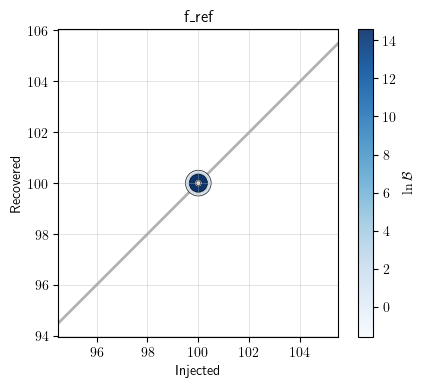

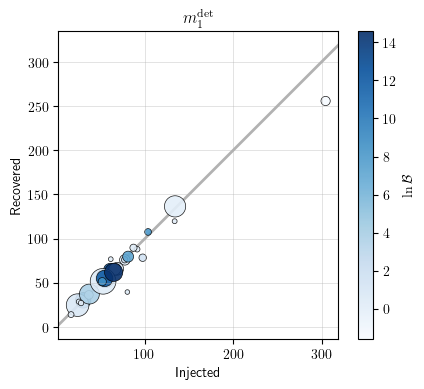

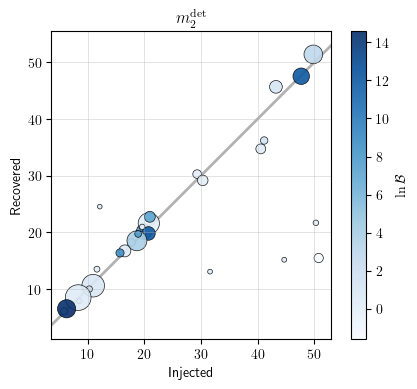

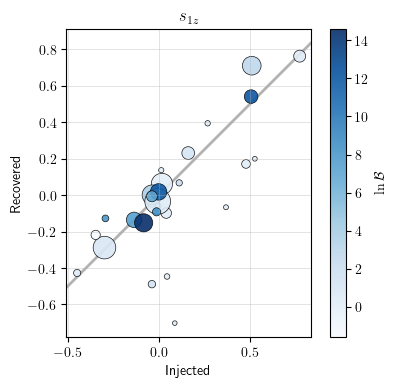

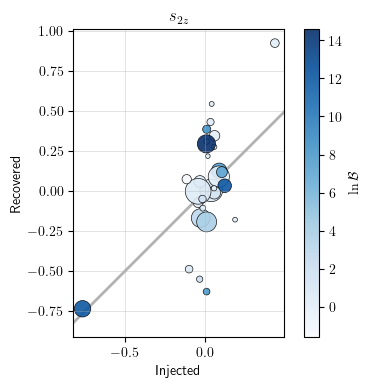

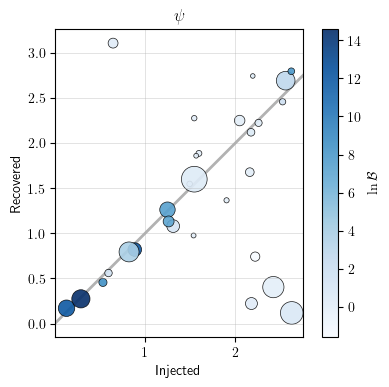

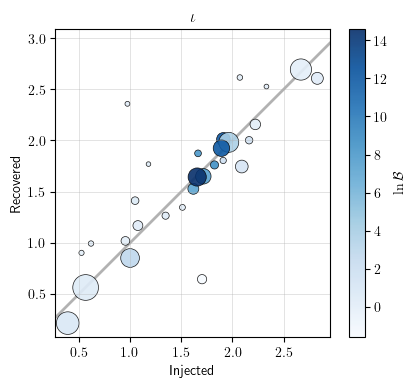

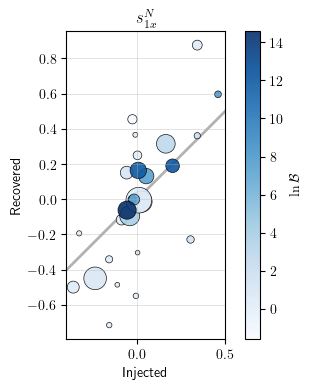

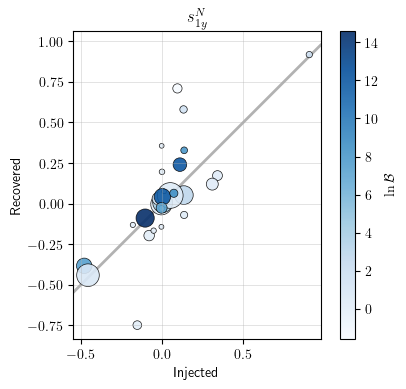

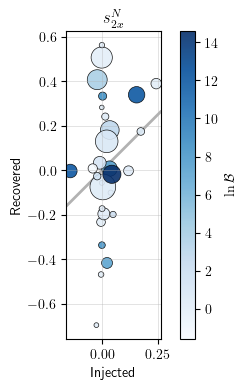

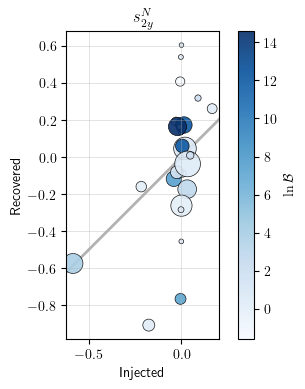

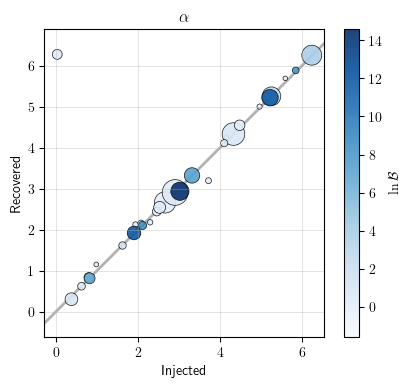

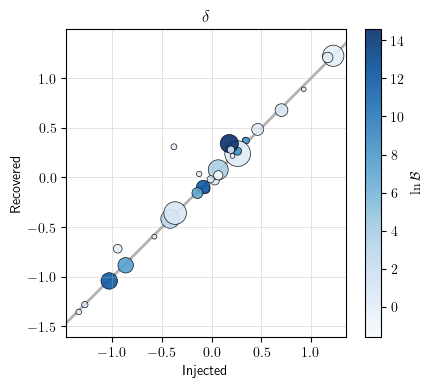

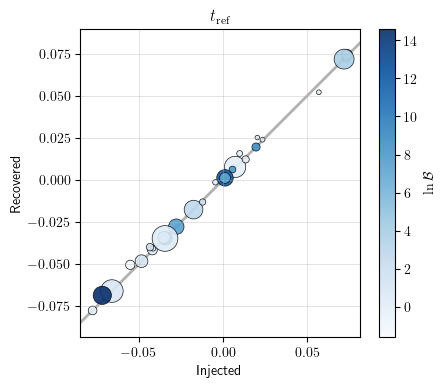

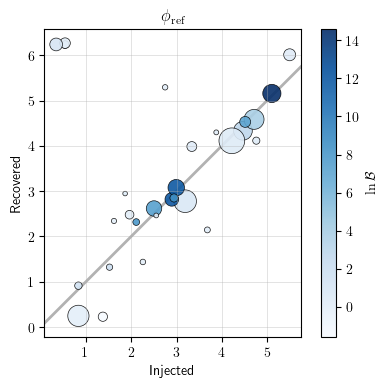

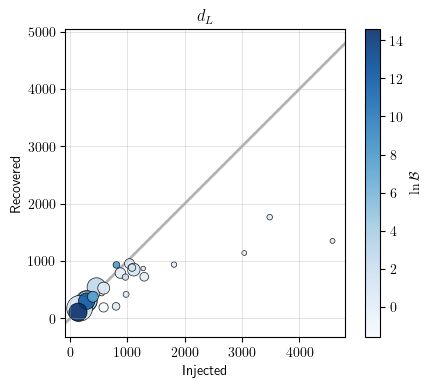

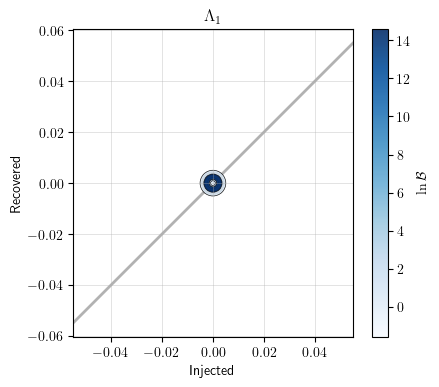

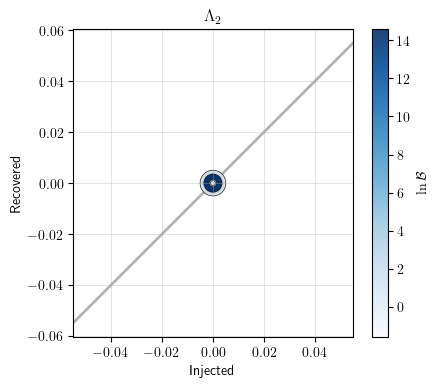

In [10]:
# let's scatter the injected vs recovered
for par_id, par_dict in params.items():
    medians, injected = np.array(list(par_dict.values())).T
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.scatter(injected, medians, **plot_kwargs)
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, alpha=0.3, c='k', lw=2, zorder=0)
    ax.set_xlim(xlim)
    ax.set_xlabel('Injected')
    ax.set_ylabel('Recovered')
    try:
        ax.set_title(gw_plotting._LABELS[par_id])
    except KeyError:
        ax.set_title(par_id)
    ax.grid(alpha=0.5, lw=0.5)
    fig.colorbar(im, ax=ax, label=r'$\ln\mathcal B$')#r'SNR $\rho^2$')
    ax.set_aspect('equal')

In [11]:
# wrap the iotas
medians, injected = np.array(list(params['iota'].values())).T
rec_iotas_wrapped = np.array([
    np.min([iota, np.pi - iota]) for iota in medians.flatten()
])
inj_iotas_wrapped = np.array([
    np.min([iota, np.pi - iota]) for iota in injected.flatten()
])

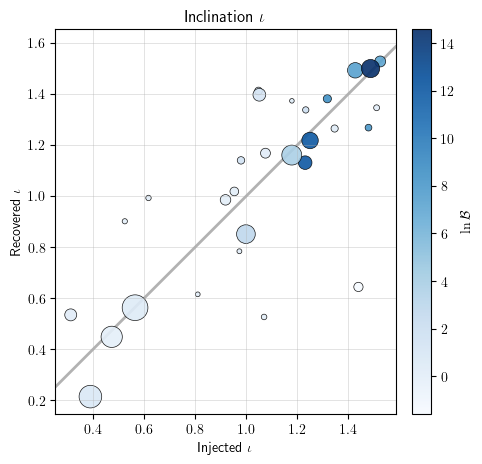

In [12]:
fig, ax = plt.subplots(figsize=(7,5))
im = ax.scatter(inj_iotas_wrapped, rec_iotas_wrapped, **plot_kwargs)
xlim = ax.get_xlim()
ax.plot(xlim, xlim, alpha=0.3, c='k', lw=2, zorder=0)
ax.set_xlim(xlim)
ax.set_xlabel(r'Injected $\iota$')
ax.set_ylabel(r'Recovered $\iota$')
ax.set_title(r'Inclination $\iota$')
ax.grid(alpha=0.5, lw=0.5)
fig.colorbar(im, ax=ax, label=r'$\ln\mathcal B$', pad=0.03)
ax.set_aspect('equal')

In [13]:
# compute the mismatch quantity
lnB = np.array([x[0] for x in lnBayes.values()])
mismatch = lnB / np.array(list(h_h.values()))

Text(0.45, 0.93, 'Injections')

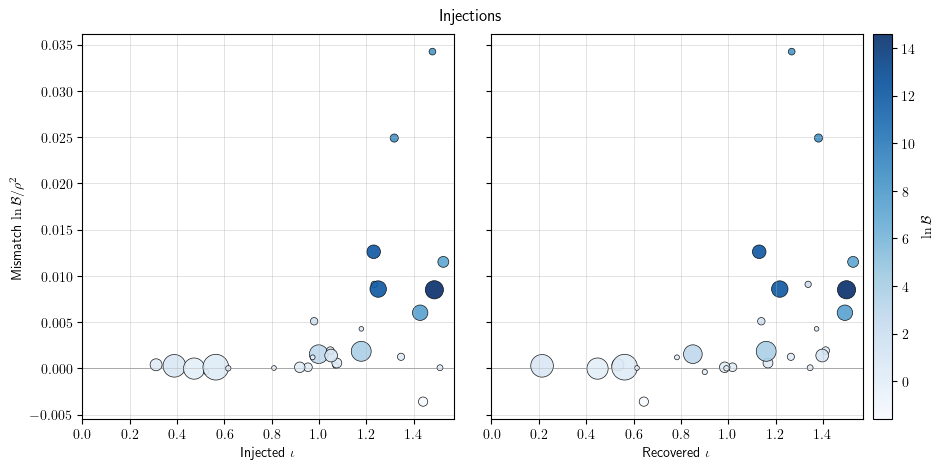

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12,5), gridspec_kw=dict(wspace=0.1))
xticks = np.arange(0., 0.51, 0.1) * np.pi
xticklabels = [f'{x / np.pi:.1f}'+r'$\pi$' for x in xticks]
for (ax, iotas, label) in zip(axs, [inj_iotas_wrapped, rec_iotas_wrapped], ['Injected', 'Recovered']):
    im = ax.scatter(iotas, mismatch, **plot_kwargs)
    ax.axhline(0., c='k', alpha=0.5, lw=0.5, zorder=0)
    ax.set_xlabel(label + r' $\iota$')
    # ax.set_xticks(xticks, labels=xticklabels)
    ax.set_xlim(0., np.pi/2)
    ax.grid(alpha=0.5, lw=0.5)
axs[0].set_ylabel(r'Mismatch $\ln\mathcal B/\rho^2$')
axs[1].set_yticklabels([])
fig.colorbar(im, ax=axs, label=r'$\ln\mathcal B$', pad=0.01)
fig.suptitle(r'Injections', x=0.45, y=0.93)

Text(0.45, 0.93, 'Injections')

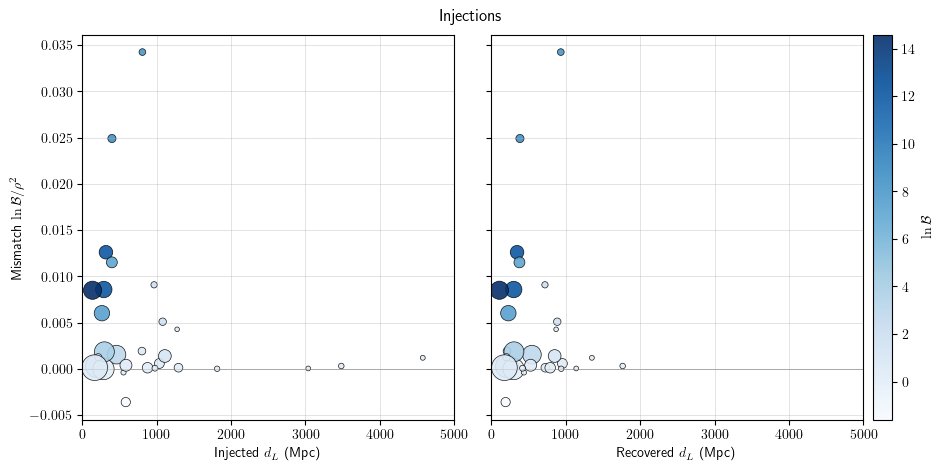

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12,5), gridspec_kw=dict(wspace=0.1))
par_id = 'd_luminosity'
rec_par, inj_par = np.array(list(params[par_id].values())).T
par_id_label = gw_plotting._LABELS[par_id] + r' (Mpc)'
for (ax, par, label) in zip(axs, [inj_par, rec_par], ['Injected', 'Recovered']):
    im = ax.scatter(par, mismatch, **plot_kwargs)
    ax.axhline(0., c='k', alpha=0.5, lw=0.5, zorder=0)
    ax.set_xlabel(label+' '+par_id_label)
    # ax.set_xticks(xticks, labels=xticklabels)
    ax.set_xlim(0., 5000)
    ax.grid(alpha=0.5, lw=0.5)
axs[0].set_ylabel(r'Mismatch $\ln\mathcal B/\rho^2$')
axs[1].set_yticklabels([])
fig.colorbar(im, ax=axs, label=r'$\ln\mathcal B$', pad=0.01)
fig.suptitle(r'Injections', x=0.45, y=0.93)

In [17]:
# what's the event with the highest mismatch?
idx_max = idx_existing[np.argmax(mismatch)]
# load this sample
eventname = f'GW{seed}_{idx_max}'
eventdir = os.path.join(resdir, eventname)
event_data, samples = load_event_data_and_posterior_samples(eventdir, eventname)
# what are the injected parameters?
injected_par_dict = event_data.get_init_dict()['injection']['par_dic']
for key, value in injected_par_dict.items():
    print(f"{key:<15}: {value:10.4f}")

loaded posterior samples for GW12_28 run 0
f_ref          :   100.0000
m1             :   107.5172
m2             :    19.7013
s1z            :    -0.1277
s2z            :    -0.6307
psi            :     2.7931
iota           :     1.8739
s1x_n          :     0.5966
s1y_n          :     0.3281
s2x_n          :    -0.3362
s2y_n          :    -0.0960
ra             :     5.8827
dec            :     0.3709
t_geocenter    :     0.0062
phi_ref        :     2.3167
d_luminosity   :   931.7501
l1             :     0.0000
l2             :     0.0000


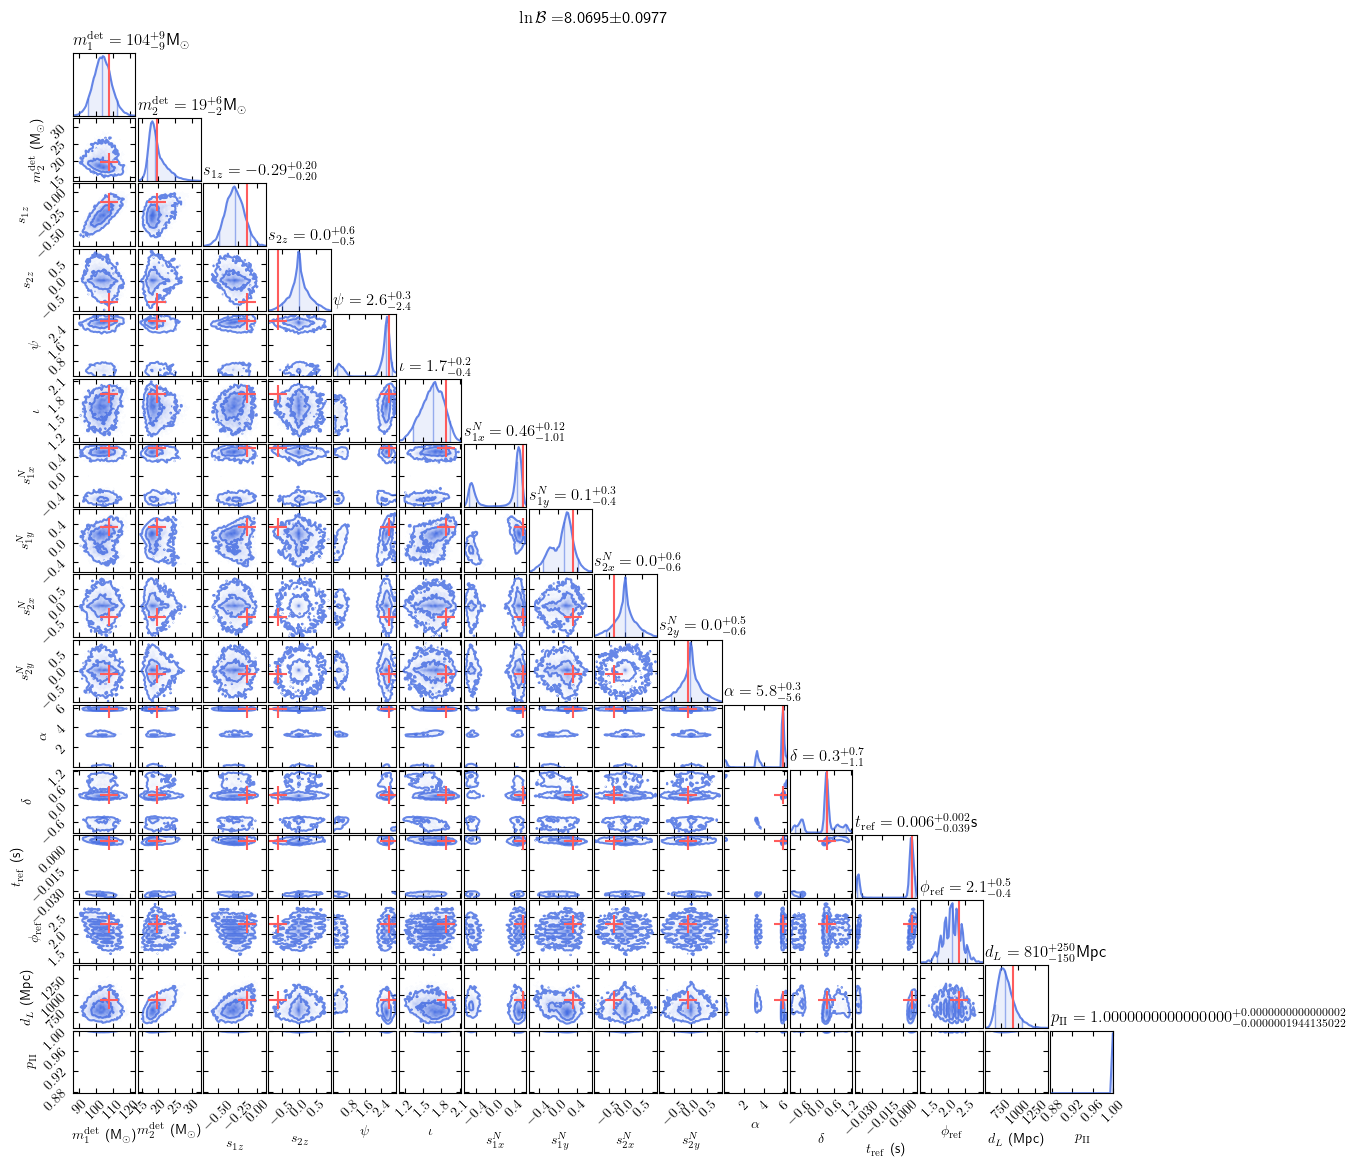

In [ ]:
# corner plot
pars_to_plot = list(params.keys()) + ['p_lensed']
for par in ['f_ref', 'l1', 'l2']:
    pars_to_plot.remove(par)
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))
corner_plot = gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)

lnbayes, lnbayes_std = lnBayes[idx_max]
title_str = r'$\ln\mathcal B =$'f'{lnbayes:.4f}'r'$\pm$' + f'{lnbayes_std:.4f}'
corner_plot.plot(max_figsize=12)
corner_plot.fig.suptitle(title_str, y=0.97) # .corner_plots[0]
corner_plot.scatter_points(injected_par_dict, colors=['#FF5C5C'], s=150,
                                    zorder=2, marker='+', adjust_lims=True)

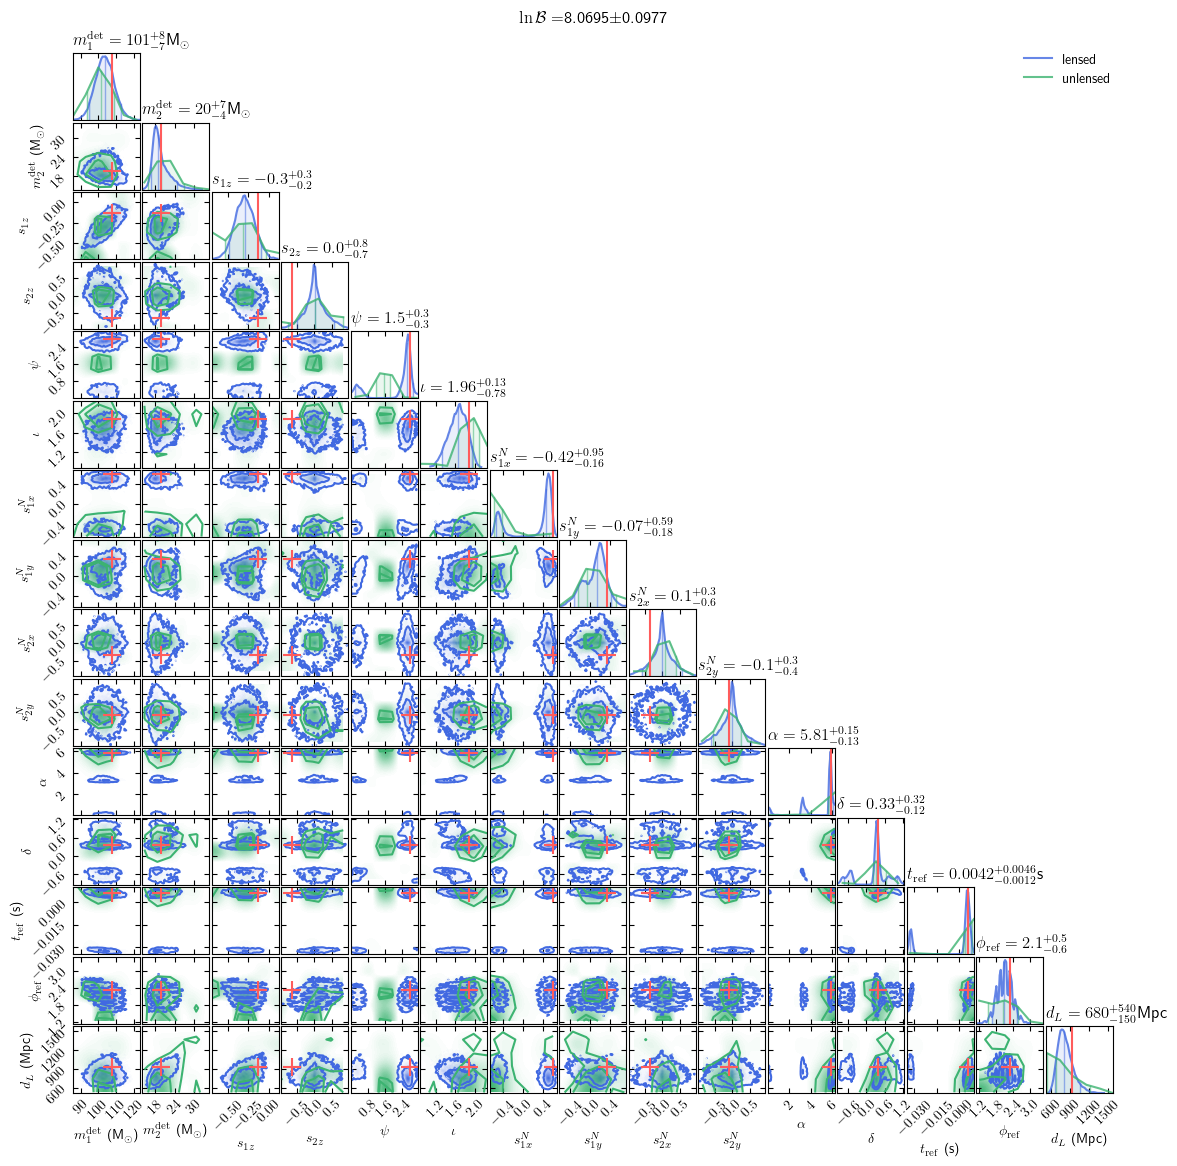

In [31]:
# corner plot: lensed vs unlensed samples
pars_to_plot = list(params.keys())
for par in ['f_ref', 'l1', 'l2']:
    pars_to_plot.remove(par)

# compare the posteriors between the lensed and unlensed samples
lensed_idx = samples['lensed']

c1, c2 = 'royalblue', 'mediumseagreen'
plotstyles = [
        plotting.PlotStyle(color_2d=c1, kwargs_1d=dict(color=c1, alpha=0.8), tail_probability=1e-3),
        plotting.PlotStyle(color_2d=c2, kwargs_1d=dict(color=c2, alpha=0.8), tail_probability=1e-3)
]

corner_plot = gw_plotting.MultiCornerPlot(
        {'lensed' : samples[lensed_idx], 'unlensed' : samples[~lensed_idx]}, params=pars_to_plot,
        density=False, plotstyles=plotstyles
)
lnbayes, lnbayes_std = lnBayes[idx_max]
title_str = r'$\ln\mathcal B =$'f'{lnbayes:.4f}'r'$\pm$' + f'{lnbayes_std:.4f}'
corner_plot.plot(max_figsize=12)
corner_plot.corner_plots[0].fig.suptitle(title_str, y=0.97)
corner_plot.scatter_points(injected_par_dict, colors=['#FF5C5C'], s=150,
                                    zorder=2, marker='+', adjust_lims=True)

In [43]:
# same thing but for the event with the second-highest mismatch
idx = idx_existing[np.where((mismatch > 0.02) & (mismatch < 0.03))[0][0]]
# load this sample
eventname = f'GW{seed}_{idx}'
eventdir = os.path.join(resdir, eventname)
event_data, samples = load_event_data_and_posterior_samples(eventdir, eventname)
# what are the injected parameters?
injected_par_dict = event_data.get_init_dict()['injection']['par_dic']

loaded posterior samples for GW12_43 run 0


Error in callback <function _draw_all_if_interactive at 0x7f06677c1ee0> (for post_execute), with arguments args (),kwargs {}:


OSError: [Errno 39] Directory not empty: '/home/abbye.williams/.cache/matplotlib/tex.cache/11/74/tmpzl8ocjc6'

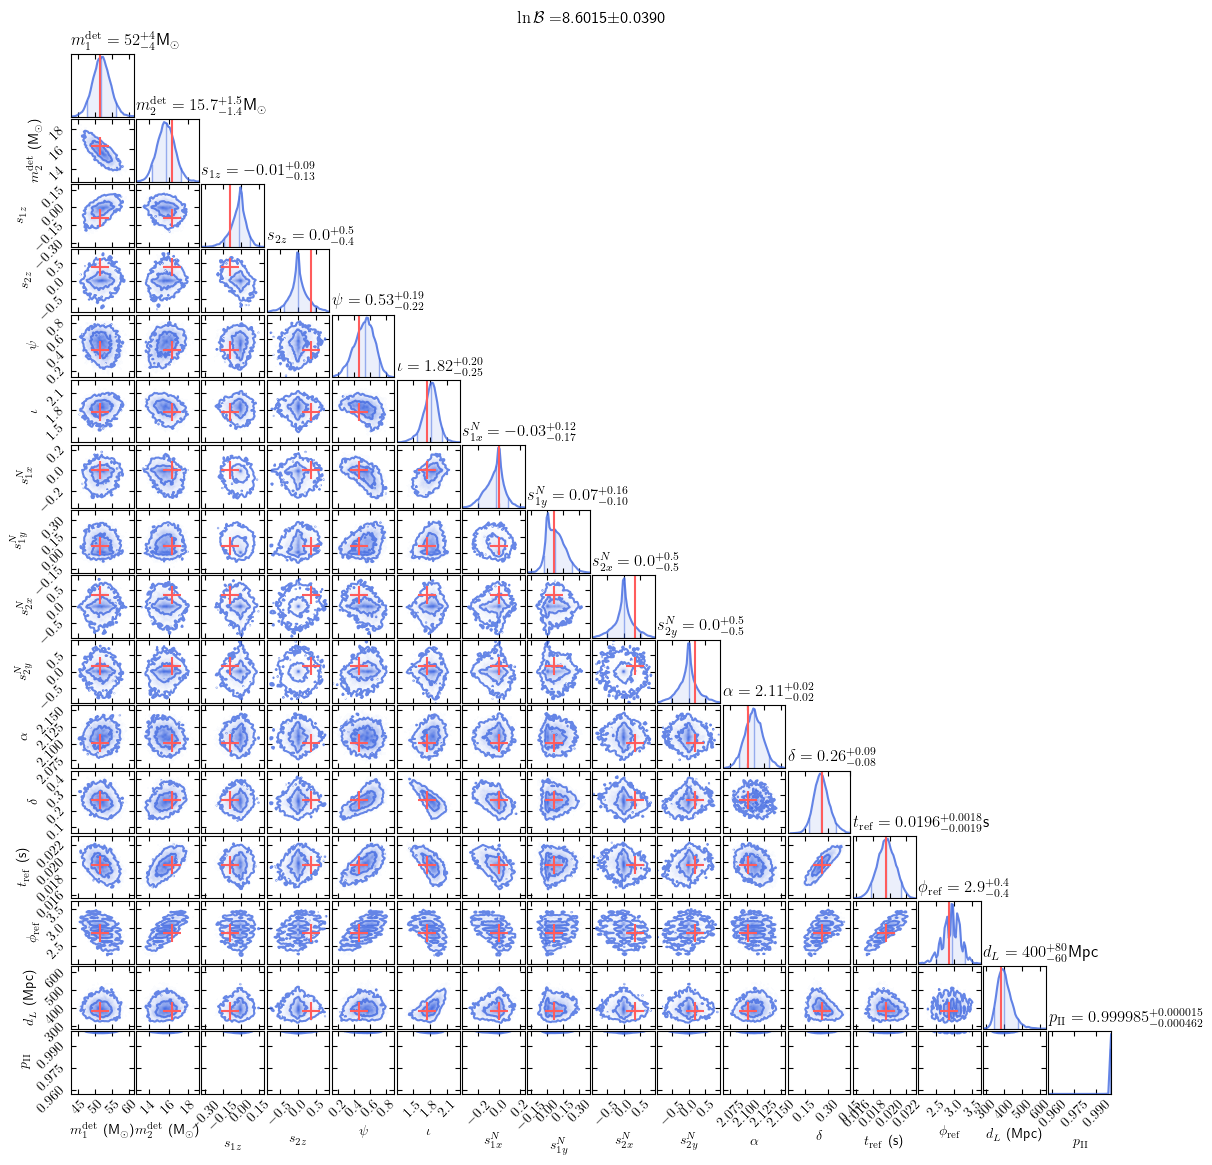

In [44]:
# corner plot
pars_to_plot = list(params.keys()) + ['p_lensed']
for par in ['f_ref', 'l1', 'l2']:
    pars_to_plot.remove(par)
corner_plot_kwargs = dict(tail_probability=1e-3, color_2d='royalblue',
    kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8))
corner_plot = gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)

lnbayes, lnbayes_std = lnBayes[idx]
title_str = r'$\ln\mathcal B =$'f'{lnbayes:.4f}'r'$\pm$' + f'{lnbayes_std:.4f}'
corner_plot.plot(max_figsize=12)
corner_plot.fig.suptitle(title_str, y=0.97) # .corner_plots[0]
corner_plot.scatter_points(injected_par_dict, colors=['#FF5C5C'], s=150,
                                    zorder=2, marker='+', adjust_lims=True)

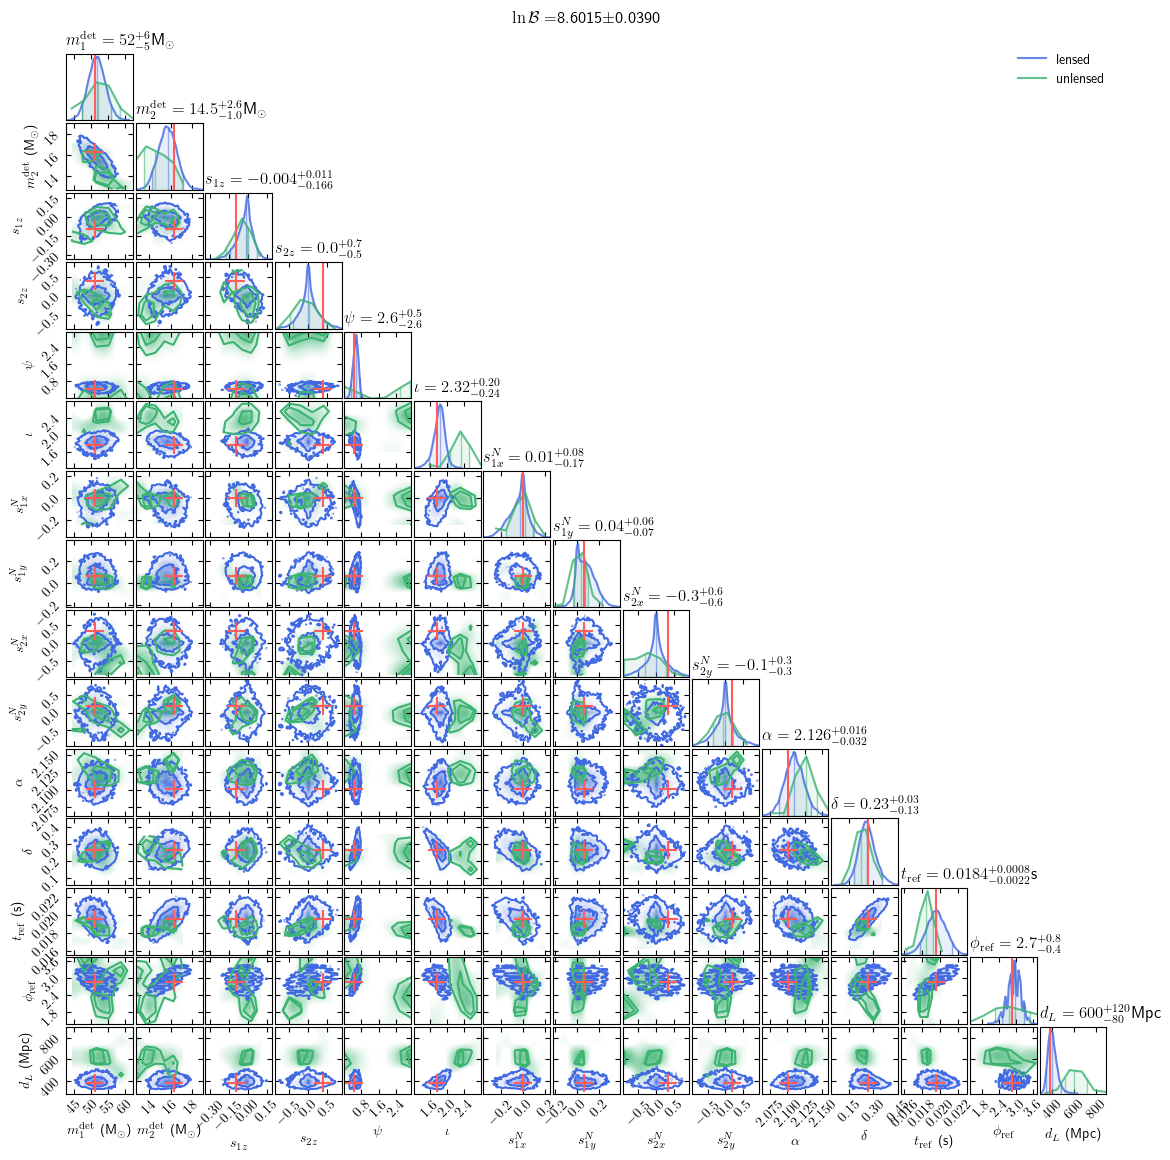

In [45]:
# corner plot: lensed vs unlensed samples
pars_to_plot = list(params.keys())
for par in ['f_ref', 'l1', 'l2']:
    pars_to_plot.remove(par)

# compare the posteriors between the lensed and unlensed samples
lensed_idx = samples['lensed']

c1, c2 = 'royalblue', 'mediumseagreen'
plotstyles = [
        plotting.PlotStyle(color_2d=c1, kwargs_1d=dict(color=c1, alpha=0.8), tail_probability=1e-3),
        plotting.PlotStyle(color_2d=c2, kwargs_1d=dict(color=c2, alpha=0.8), tail_probability=1e-3)
]

corner_plot = gw_plotting.MultiCornerPlot(
        {'lensed' : samples[lensed_idx], 'unlensed' : samples[~lensed_idx]}, params=pars_to_plot,
        density=False, plotstyles=plotstyles
)
lnbayes, lnbayes_std = lnBayes[idx]
title_str = r'$\ln\mathcal B =$'f'{lnbayes:.4f}'r'$\pm$' + f'{lnbayes_std:.4f}'
corner_plot.plot(max_figsize=12)
corner_plot.corner_plots[0].fig.suptitle(title_str, y=0.97)
corner_plot.scatter_points(injected_par_dict, colors=['#FF5C5C'], s=150,
                                    zorder=2, marker='+', adjust_lims=True)